<br>

# Proyecto Final codigo



<div align="center">
  <img src="icon.jpeg" alt="Logo o Imagen de Portada" width="700"/>
</div>



### **Información del Proyecto**

**Materia:** *Simulación de Procesos Financieros*

**Integrantes:** 
* Marcelo Ballesteros  
* Alejandro García  

**Fecha de entrega:** *7 de mayo de 2026*

<br>

---

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
from datetime import date
from scipy.stats import norm
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

PARÁMETROS DEL MODELO - PLTR
Precio Spot (S0): $137.25
Strike (K): $130.00 (Aprox 5% OTM)
Volatilidad Anualizada: 51.33%
Tasa Libre de Riesgo (r): 4.5%
Tiempo al Vencimiento (T): 0.5 años
--------------------------------------------------
Precio Teórico de la Prima (Put): $14.38
Costo Total de la Estrategia (Acción + Put): $151.63
--------------------------------------------------
GRIEGAS DE LA OPCIÓN PUT:
Delta: -0.3472 | Gamma: 0.0074 | Vega: 35.8403 | Theta: -0.0428 (diario)
Delta Neto de la Estrategia (Protective Put): 0.6528


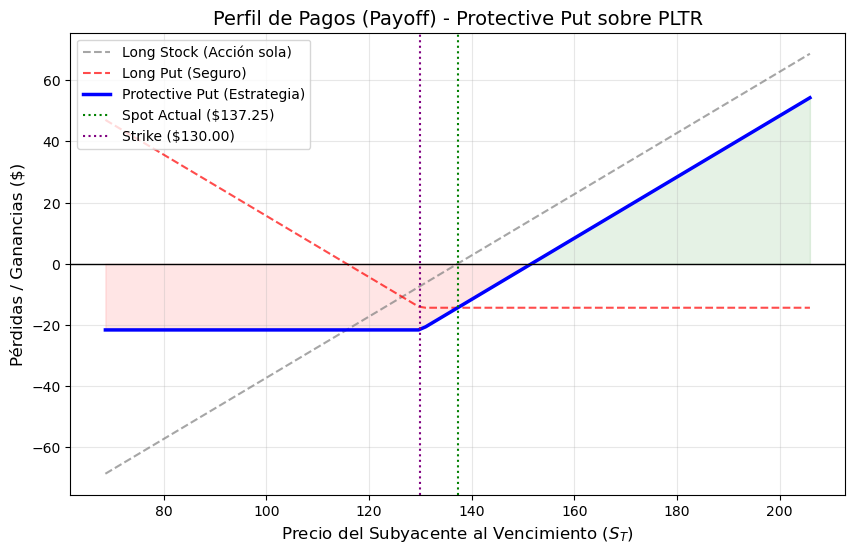

In [2]:
# 1. Función de Black-Scholes para Precio y Griegas (enfocado en Put)
def black_scholes_put(S, K, r, T, sigma):
    # D1 y D2
    d1 = (np.log(S/K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    
    # Precio Teórico del Put
    put_price = K * np.exp(-r*T) * norm.cdf(-d2) - S * norm.cdf(-d1)
    
    # Griegas del Put
    delta = norm.cdf(d1) - 1
    gamma = norm.pdf(d1) / (S * sigma * np.sqrt(T))
    theta = -(S * norm.pdf(d1) * sigma) / (2 * np.sqrt(T)) + r * K * np.exp(-r*T) * norm.cdf(-d2)
    vega = S * norm.pdf(d1) * np.sqrt(T)
    rho = -K * T * np.exp(-r*T) * norm.cdf(-d2)
    
    return put_price, delta, gamma, theta, vega, rho

# 2. Obtención de datos reales (PLTR)
ticker = 'PLTR'
tk = yf.Ticker(ticker)
data = tk.history(period='1y')

# Parámetros del mercado
S0 = float(data['Close'].iloc[-1]) # Precio Spot actual
sigma = data['Close'].pct_change().std() * np.sqrt(252) # Volatilidad histórica anualizada
r = 0.045 # Tasa libre de riesgo (aprox 4.5%)
T = 0.5 # Tiempo al vencimiento (6 meses = 0.5 años)
K = round(S0 * 0.95, 0) # Strike (Aproximadamente 5% OTM para abaratar la prima)

# 3. Cálculo de la prima y griegas
put_price, p_delta, p_gamma, p_theta, p_vega, p_rho = black_scholes_put(S0, K, r, T, sigma)

# Griegas de la Estrategia (Protective Put = Long Stock + Long Put)
# El Delta de 1 acción es 1. 
strat_delta = 1 + p_delta 
strat_gamma = p_gamma
strat_vega = p_vega

print("="*50)
print(f"PARÁMETROS DEL MODELO - {ticker}")
print(f"Precio Spot (S0): ${S0:.2f}")
print(f"Strike (K): ${K:.2f} (Aprox 5% OTM)")
print(f"Volatilidad Anualizada: {sigma*100:.2f}%")
print(f"Tasa Libre de Riesgo (r): {r*100}%")
print(f"Tiempo al Vencimiento (T): {T} años")
print("-" * 50)
print(f"Precio Teórico de la Prima (Put): ${put_price:.2f}")
print(f"Costo Total de la Estrategia (Acción + Put): ${(S0 + put_price):.2f}")
print("-" * 50)
print("GRIEGAS DE LA OPCIÓN PUT:")
print(f"Delta: {p_delta:.4f} | Gamma: {p_gamma:.4f} | Vega: {p_vega:.4f} | Theta: {p_theta/365:.4f} (diario)")
print(f"Delta Neto de la Estrategia (Protective Put): {strat_delta:.4f}")
print("="*50)

# 4. Modelado y Gráfica del Payoff
ST = np.linspace(S0 * 0.5, S0 * 1.5, 100) # Escenarios de precio al vencimiento

# Payoffs individuales
payoff_stock = ST - S0
payoff_put = np.maximum(K - ST, 0) - put_price

# Payoff de la estrategia (Protective Put)
payoff_strategy = payoff_stock + payoff_put

plt.figure(figsize=(10, 6))
plt.plot(ST, payoff_stock, '--', color='grey', alpha=0.7, label='Long Stock (Acción sola)')
plt.plot(ST, payoff_put, '--', color='red', alpha=0.7, label='Long Put (Seguro)')
plt.plot(ST, payoff_strategy, '-', color='blue', linewidth=2.5, label='Protective Put (Estrategia)')

# Marcas importantes
plt.axhline(0, color='black', linewidth=1)
plt.axvline(S0, color='green', linestyle=':', label=f'Spot Actual (${S0:.2f})')
plt.axvline(K, color='purple', linestyle=':', label=f'Strike (${K:.2f})')

# Rellenar el área de pérdida máxima y ganancia
plt.fill_between(ST, payoff_strategy, 0, where=(payoff_strategy < 0), color='red', alpha=0.1)
plt.fill_between(ST, payoff_strategy, 0, where=(payoff_strategy > 0), color='green', alpha=0.1)

plt.title(f'Perfil de Pagos (Payoff) - Protective Put sobre {ticker}', fontsize=14)
plt.xlabel('Precio del Subyacente al Vencimiento ($S_T$)', fontsize=12)
plt.ylabel('Pérdidas / Ganancias ($)', fontsize=12)
plt.legend(loc='upper left')
plt.grid(alpha=0.3)
plt.show()

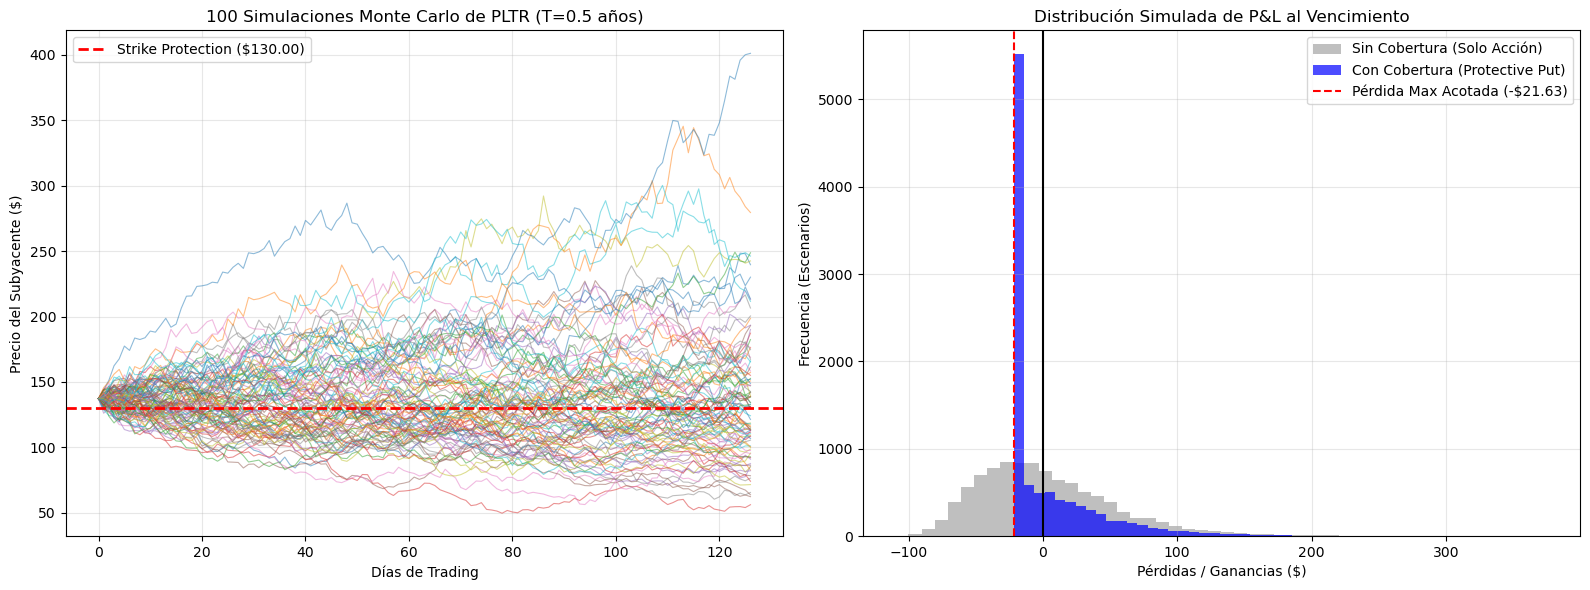

RESULTADOS DE LA SIMULACIÓN MONTE CARLO (10,000 Escenarios)
--------------------------------------------------
Valor en Riesgo (VaR 95%) SIN cobertura: $-65.54
Valor en Riesgo (VaR 95%) CON cobertura: $-21.63
Pérdida Máxima Teórica Estricta (Protective Put): -$21.63


In [3]:
# 5. Simulación Monte Carlo (Movimiento Browniano Geométrico)
np.random.seed(42) # Semilla para reproducibilidad

# Parámetros de la simulación
num_simulations = 10000
num_days = int(T * 252) # Días de trading al vencimiento (aprox 126 para 0.5 años)
dt = T / num_days

# Matriz para almacenar las trayectorias de precios (Días x Simulaciones)
simulated_paths = np.zeros((num_days + 1, num_simulations))
simulated_paths[0] = S0

# Generación de los caminos estocásticos (GBM)
for t in range(1, num_days + 1):
    Z = np.random.standard_normal(num_simulations)
    simulated_paths[t] = simulated_paths[t-1] * np.exp((r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z)

# Extracción de los precios simulados al vencimiento (S_T)
ST_simulated = simulated_paths[-1]

# 6. Cálculo de Payoffs Simulados
# Acción Sola
payoff_stock_sim = ST_simulated - S0

# Protective Put (Acción + Put)
# El Put paga max(K - ST, 0) pero costó put_price
payoff_put_sim = np.maximum(K - ST_simulated, 0) - put_price
payoff_strategy_sim = payoff_stock_sim + payoff_put_sim

# 7. Visualización de Resultados: Trayectorias y Distribución de Retornos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Primeras 100 trayectorias de Monte Carlo
ax1.plot(simulated_paths[:, :100], alpha=0.5, linewidth=0.8)
ax1.axhline(K, color='red', linestyle='--', linewidth=2, label=f'Strike Protection (${K:.2f})')
ax1.set_title(f'100 Simulaciones Monte Carlo de PLTR (T={T} años)')
ax1.set_xlabel('Días de Trading')
ax1.set_ylabel('Precio del Subyacente ($)')
ax1.legend()
ax1.grid(alpha=0.3)

# Gráfico 2: Histograma comparativo de Pérdidas y Ganancias al Vencimiento
ax2.hist(payoff_stock_sim, bins=50, alpha=0.5, color='grey', label='Sin Cobertura (Solo Acción)')
ax2.hist(payoff_strategy_sim, bins=50, alpha=0.7, color='blue', label='Con Cobertura (Protective Put)')
ax2.axvline(0, color='black', linestyle='-')

# Marcador visual de la pérdida máxima acotada
max_loss_strat = (S0 - K) + put_price
ax2.axvline(-max_loss_strat, color='red', linestyle='--', label=f'Pérdida Max Acotada (-${max_loss_strat:.2f})')

ax2.set_title('Distribución Simulada de P&L al Vencimiento')
ax2.set_xlabel('Pérdidas / Ganancias ($)')
ax2.set_ylabel('Frecuencia (Escenarios)')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 8. Métricas de Riesgo Comparativas (VaR Probabilístico)
var_95_stock = np.percentile(payoff_stock_sim, 5)
var_95_strat = np.percentile(payoff_strategy_sim, 5)

print("="*50)
print("RESULTADOS DE LA SIMULACIÓN MONTE CARLO (10,000 Escenarios)")
print("-" * 50)
print(f"Valor en Riesgo (VaR 95%) SIN cobertura: ${var_95_stock:.2f}")
print(f"Valor en Riesgo (VaR 95%) CON cobertura: ${var_95_strat:.2f}")
print(f"Pérdida Máxima Teórica Estricta (Protective Put): -${max_loss_strat:.2f}")
print("="*50)

## Anexos
GitHub Alejandro Garcia: https://github.com/Alejandro-Garcia-04/Simulacion_de_procesos_financieros/tree/main

GitHub Marcelo Ballesteros: https://github.com/Chelito123/SImulacion-de-procesos-financieros